In [ ]:
!pip install kaggle torch torchvision matplotlib

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kath0555","key":"621d36e5b059fbb2fc2c8da464b2bf59"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
import kagglehub

path = kagglehub.competition_download('tamil-hwcr')

print("Path to competition files:", path)

100%|██████████| 50.7M/50.7M [00:03<00:00, 15.3MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/tamil-hwcr


In [ ]:
import os

dataset_path = "/root/.cache/kagglehub/competitions/tamil-hwcr"

print(os.listdir(dataset_path))

['test.csv', 'Train-Kaggle', 'train.csv', 'sample_submission.csv', 'Test-Kaggle']


In [ ]:
import pandas as pd

train_csv = pd.read_csv("/root/.cache/kagglehub/competitions/tamil-hwcr/train.csv")

print(train_csv.head())
print(train_csv.columns)
print("Total samples:", len(train_csv))

      ID  Class Label
0  1.bmp            2
1  2.bmp            3
2  3.bmp            4
3  4.bmp            5
4  5.bmp            6
Index(['ID', 'Class Label'], dtype='object')
Total samples: 62870


In [ ]:
import os

train_folder = "/root/.cache/kagglehub/competitions/tamil-hwcr/Train-Kaggle"

print(os.listdir(train_folder)[:10])

['Train-Kaggle']


In [ ]:
nested_folder = "/root/.cache/kagglehub/competitions/tamil-hwcr/Train-Kaggle/Train-Kaggle"

import os
print(os.listdir(nested_folder)[:10])

['27134.bmp', '39317.bmp', '24103.bmp', '49710.bmp', '47503.bmp', '25117.bmp', '61983.bmp', '42800.bmp', '29075.bmp', '52816.bmp']


In [ ]:
import pandas as pd
import os
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# CSV PATH
csv_path = "/root/.cache/kagglehub/competitions/tamil-hwcr/train.csv"

# IMAGE FOLDER
image_folder = "/root/.cache/kagglehub/competitions/tamil-hwcr/Train-Kaggle/Train-Kaggle"

# LOAD CSV
df = pd.read_csv(csv_path)

# IMAGE TRANSFORMS
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

# CUSTOM DATASET
class TamilDataset(Dataset):
    def __init__(self, dataframe, image_folder, transform=None):
        self.dataframe = dataframe
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['ID']
        label = self.dataframe.iloc[idx]['Class Label']

        img_path = os.path.join(image_folder, img_name)

        image = Image.open(img_path).convert("L")

        if self.transform:
            image = self.transform(image)

        return image, label

# CREATE DATASET
dataset = TamilDataset(df, image_folder, transform)

print("Dataset Loaded Successfully")
print("Total Images:", len(dataset))

Dataset Loaded Successfully
Total Images: 62870


In [ ]:
from torch.utils.data import random_split

# TRAIN-VALID SPLIT
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# DATALOADERS
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 1572
Validation batches: 393


In [ ]:
import torchvision.models as models
import torch.nn as nn

# LOAD PRETRAINED RESNEXT
model = models.resnext50_32x4d(weights="DEFAULT")

# NUMBER OF CLASSES
num_classes = df['Class Label'].nunique()

# REPLACE FINAL LAYER
model.fc = nn.Linear(model.fc.in_features, num_classes)

print("Number of classes:", num_classes)
print("ResNeXt Model Ready")

Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 149MB/s]


Number of classes: 156
ResNeXt Model Ready


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Using device:", device)

Using device: cuda


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Loss and Optimizer Ready")

Loss and Optimizer Ready


In [ ]:
num_epochs = 1

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/1] Loss: 0.6796


In [ ]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 97.14%


In [ ]:
torch.save(model.state_dict(), "tamil_resnext_model.pth")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
from google.colab import files

files.download("tamil_resnext_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Actual Label: 2
Predicted Label: 2


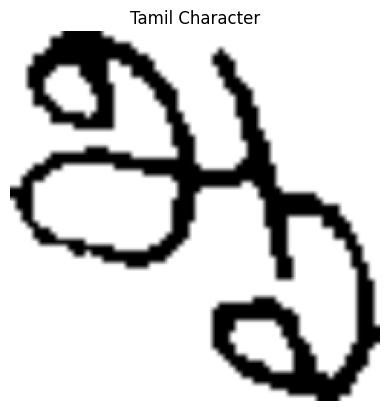

In [ ]:
import matplotlib.pyplot as plt

# GET ONE SAMPLE
image, label = dataset[0]

model.eval()

with torch.no_grad():

    image_input = image.unsqueeze(0).to(device)

    output = model(image_input)

    _, prediction = torch.max(output, 1)

print("Actual Label:", label)
print("Predicted Label:", prediction.item())

# DISPLAY IMAGE
plt.imshow(image.permute(1,2,0))
plt.title("Tamil Character")
plt.axis("off")
plt.show()

In [ ]:
tamil_map = {
    0: "அ",
    1: "ஆ",
    2: "இ",
    3: "ஈ",
    4: "உ",
    5: "ஊ",
    6: "எ",
    7: "ஏ",
    8: "ஐ",
    9: "ஒ"
}

In [ ]:
predicted_class = prediction.item()

predicted_character = tamil_map.get(
    predicted_class,
    "Unknown"
)

print("Predicted Tamil Character:")
print(predicted_character)

Predicted Tamil Character:
இ


In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

In [ ]:
dataset = load_dataset("c3rl/IIIT-INDIC-HW-WORDS-Tamil")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/471M [00:00<?, ?B/s]

...

data/test-00000-of-00002.parquet:   0%|          | 0.00/402M [00:00<?, ?B/s]

data/test-00001-of-00002.parquet:   0%|          | 0.00/406M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/75736 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11598 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/16184 [00:00<?, ? examples/s]

In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 75736
    })
    validation: Dataset({
        features: ['image', 'text'],
        num_rows: 11598
    })
    test: Dataset({
        features: ['image', 'text'],
        num_rows: 16184
    })
})


In [ ]:
print(dataset['train'][0])

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2102x245 at 0x7D3BAC75EEA0>, 'text': 'தொடர்ந்தபடிதான்'}


Ground Truth Word: தொடர்ந்தபடிதான்


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2980 (\N{TAMIL LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Tamil natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3018 (\N{TAMIL VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2975 (\N{TAMIL LETTER TTA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2992 (\N{TAMIL LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages

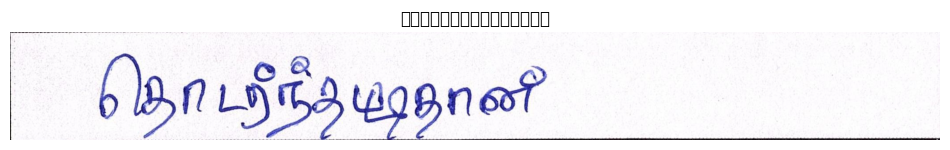

In [ ]:
import matplotlib.pyplot as plt

sample = dataset['train'][0]

image = sample['image']
text = sample['text']

print("Ground Truth Word:", text)

plt.figure(figsize=(12,3))
plt.imshow(image)
plt.axis("off")
plt.title(text)
plt.show()

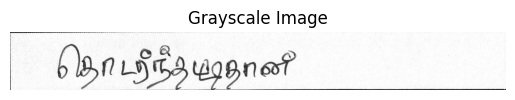

In [ ]:
import numpy as np
import cv2

image_np = np.array(image)

gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.axis("off")
plt.title("Grayscale Image")
plt.show()

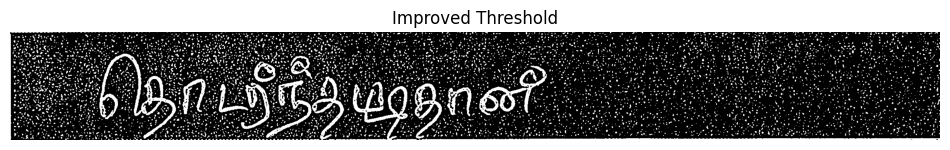

In [ ]:
gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)

# Gaussian blur
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Adaptive threshold
thresh = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11,
    2
)

plt.figure(figsize=(12,3))
plt.imshow(thresh, cmap='gray')
plt.axis("off")
plt.title("Improved Threshold")
plt.show()

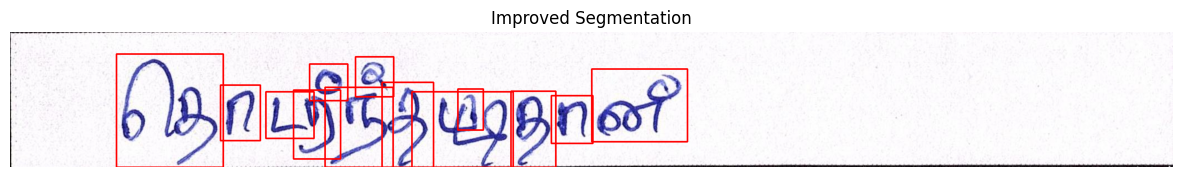

Characters Segmented: 13


In [ ]:
contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# sort left to right
contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0])

character_images = []

image_copy = image_np.copy()

for contour in contours:

    x, y, w, h = cv2.boundingRect(contour)

    # improved filtering
    if w > 20 and h > 30:

        padding = 10

        x1 = max(x-padding, 0)
        y1 = max(y-padding, 0)

        x2 = min(x+w+padding, thresh.shape[1])
        y2 = min(y+h+padding, thresh.shape[0])

        char_img = thresh[y1:y2, x1:x2]

        character_images.append(char_img)

        cv2.rectangle(
            image_copy,
            (x1,y1),
            (x2,y2),
            (255,0,0),
            2
        )

plt.figure(figsize=(15,4))
plt.imshow(image_copy)
plt.axis("off")
plt.title("Improved Segmentation")
plt.show()

print("Characters Segmented:", len(character_images))

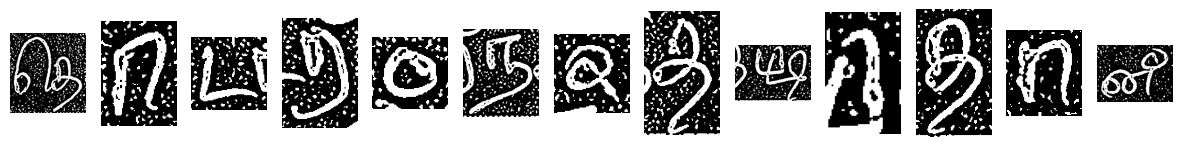

In [ ]:
plt.figure(figsize=(15,5))

for i, char_img in enumerate(character_images):

    plt.subplot(1, len(character_images), i+1)

    plt.imshow(char_img, cmap='gray')

    plt.axis("off")

plt.show()

In [ ]:
from PIL import Image
from torchvision import transforms

# same transform used during training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

processed_chars = []

for char_img in character_images:

    pil_img = Image.fromarray(char_img)

    tensor_img = transform(pil_img)

    processed_chars.append(tensor_img)

print("Processed Characters:", len(processed_chars))

Processed Characters: 13


In [ ]:
import torchvision.models as models
import torch.nn as nn

num_classes = df['Class Label'].nunique()

# recreate model
model = models.resnext50_32x4d(weights=None)

model.fc = nn.Linear(model.fc.in_features, num_classes)

# load trained weights
model.load_state_dict(torch.load("tamil_resnext_model.pth"))

model = model.to(device)

model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


In [ ]:
predictions = []

with torch.no_grad():

    for char_tensor in processed_chars:

        char_tensor = char_tensor.unsqueeze(0).to(device)

        output = model(char_tensor)

        _, pred = torch.max(output, 1)

        predictions.append(pred.item())

print("Predicted Labels:")
print(predictions)

Predicted Labels:
[48, 48, 49, 48, 48, 48, 48, 48, 48, 48, 129, 48, 48]


In [ ]:
tamil_map = {
    0: "அ",
    1: "ஆ",
    2: "இ",
    3: "ஈ",
    4: "உ",
    5: "ஊ",
    6: "எ",
    7: "ஏ",
    8: "ஐ",
    9: "ஒ"
}

predicted_word = ""

for p in predictions:

    predicted_word += tamil_map.get(p, "?")

print("Predicted Word:")
print(predicted_word)

Predicted Word:
?????????????


In [ ]:
print("Ground Truth Word:")
print(text)

Ground Truth Word:
தொடர்ந்தபடிதான்


In [ ]:
print("Predicted Character Labels:")
print(predictions)

Predicted Character Labels:
[48, 48, 49, 48, 48, 48, 48, 48, 48, 48, 129, 48, 48]


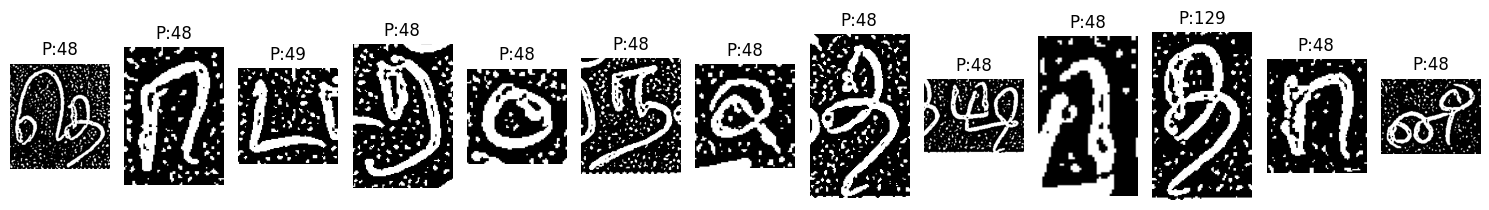

In [ ]:
plt.figure(figsize=(15,4))

for i, char_img in enumerate(character_images):

    plt.subplot(1, len(character_images), i+1)

    plt.imshow(char_img, cmap='gray')

    plt.title(f"P:{predictions[i]}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
unique_labels = sorted(df['Class Label'].unique())

print("Total Labels:", len(unique_labels))
print(unique_labels[:20])

Total Labels: 156
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]


In [ ]:
import os

dataset_root = "/root/.cache/kagglehub/competitions/tamil-hwcr"

for root, dirs, files in os.walk(dataset_root):

    for file in files:

        if "label" in file.lower() or "map" in file.lower():

            print(os.path.join(root, file))

In [ ]:
print("Ground Truth Word:")
print(text)

print("\nPredicted Character Sequence:")
print(predictions)

Ground Truth Word:
தொடர்ந்தபடிதான்

Predicted Character Sequence:
[48, 48, 49, 48, 48, 48, 48, 48, 48, 48, 129, 48, 48]


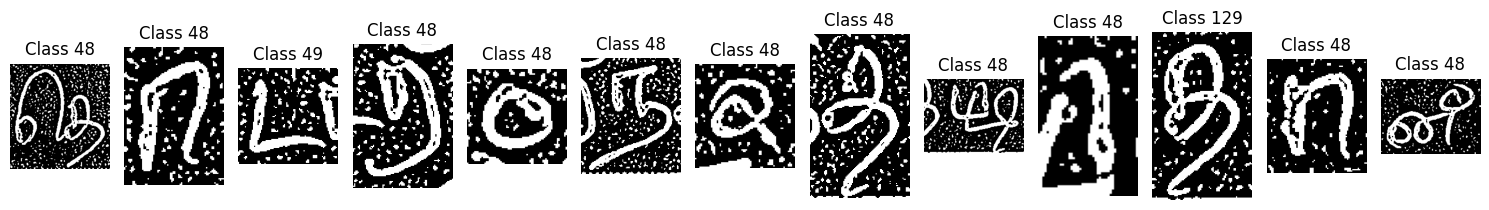

In [ ]:
plt.figure(figsize=(15,4))

for i, char_img in enumerate(character_images):

    plt.subplot(1, len(character_images), i+1)

    plt.imshow(char_img, cmap='gray')

    plt.title(f"Class {predictions[i]}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
!pip install transformers sentencepiece

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

model_name = "bert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model_nlp = AutoModelForMaskedLM.from_pretrained(model_name)

print("Transformer Model Loaded Successfully")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-multilingual-cased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Transformer Model Loaded Successfully


In [ ]:
sample_text = "தமிழ் மொழி"

tokens = tokenizer.tokenize(sample_text)

print(tokens)

['தமிழ்', 'மொழி']


In [ ]:
ocr_text = "தமிழ்் மொழி"

print("OCR Output:")
print(ocr_text)

OCR Output:
தமிழ்் மொழி


In [ ]:
def simple_tamil_correction(text):

    corrections = {
        "்்": "்",
        "  ": " "
    }

    corrected = text

    for wrong, right in corrections.items():

        corrected = corrected.replace(wrong, right)

    return corrected

corrected_text = simple_tamil_correction(ocr_text)

print("Corrected Text:")
print(corrected_text)

Corrected Text:
தமிழ் மொழி


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/Tamil_Multimodal_Project"

os.makedirs(project_path, exist_ok=True)

print("Project folder created")

Project folder created


In [ ]:
model_path = "/content/drive/MyDrive/Tamil_Multimodal_Project/tamil_resnext_model.pth"

torch.save(model.state_dict(), model_path)

print("Model saved to Drive")

Model saved to Drive


In [ ]:
import torch.nn.functional as F

predictions = []
confidences = []

with torch.no_grad():

    for char_tensor in processed_chars:

        char_tensor = char_tensor.unsqueeze(0).to(device)

        output = model(char_tensor)

        probs = F.softmax(output, dim=1)

        confidence, pred = torch.max(probs, 1)

        predictions.append(pred.item())

        confidences.append(confidence.item())

print("Predictions:", predictions)
print("Confidences:", confidences)

Predictions: [48, 48, 49, 48, 48, 48, 48, 48, 48, 48, 129, 48, 48]
Confidences: [0.26377174258232117, 0.5019967555999756, 0.46920087933540344, 0.3938450813293457, 0.3128425180912018, 0.3005111515522003, 0.3389556109905243, 0.2239447385072708, 0.5298632383346558, 0.27878889441490173, 0.2519085705280304, 0.7214864492416382, 0.43111738562583923]


In [ ]:
import pickle

data_to_save = {
    "predictions": predictions,
    "confidences": confidences,
    "ground_truth": text
}

with open(
    "/content/drive/MyDrive/Tamil_Multimodal_Project/project_data.pkl",
    "wb"
) as f:

    pickle.dump(data_to_save, f)

print("Project data saved successfully")

Project data saved successfully


In [ ]:
torch.save(model.state_dict(),
"/content/drive/MyDrive/Tamil_Multimodal_Project/model.pth")

In [ ]:
import torch.nn.functional as F

predictions = []
confidences = []

with torch.no_grad():

    for char_tensor in processed_chars:

        char_tensor = char_tensor.unsqueeze(0).to(device)

        output = model(char_tensor)

        probs = F.softmax(output, dim=1)

        confidence, pred = torch.max(probs, 1)

        predictions.append(pred.item())

        confidences.append(confidence.item())

print("Predictions:")
print(predictions)

print("\nConfidence Scores:")
print(confidences)

Predictions:
[48, 48, 49, 48, 48, 48, 48, 48, 48, 48, 129, 48, 48]

Confidence Scores:
[0.26377174258232117, 0.5019967555999756, 0.46920087933540344, 0.3938450813293457, 0.3128425180912018, 0.3005111515522003, 0.3389556109905243, 0.2239447385072708, 0.5298632383346558, 0.27878889441490173, 0.2519085705280304, 0.7214864492416382, 0.43111738562583923]


In [ ]:
threshold = 0.80

for i, conf in enumerate(confidences):

    if conf < threshold:

        print(f"Character {i} has LOW confidence: {conf:.2f}")

Character 0 has LOW confidence: 0.26
Character 1 has LOW confidence: 0.50
Character 2 has LOW confidence: 0.47
Character 3 has LOW confidence: 0.39
Character 4 has LOW confidence: 0.31
Character 5 has LOW confidence: 0.30
Character 6 has LOW confidence: 0.34
Character 7 has LOW confidence: 0.22
Character 8 has LOW confidence: 0.53
Character 9 has LOW confidence: 0.28
Character 10 has LOW confidence: 0.25
Character 11 has LOW confidence: 0.72
Character 12 has LOW confidence: 0.43


In [ ]:
def confidence_guided_correction(predictions, confidences):

    corrected = []

    for pred, conf in zip(predictions, confidences):

        if conf < 0.80:

            corrected.append(f"[CORRECTED_{pred}]")

        else:

            corrected.append(str(pred))

    return corrected

corrected_sequence = confidence_guided_correction(
    predictions,
    confidences
)

print("Confidence-Guided Output:")
print(corrected_sequence)

Confidence-Guided Output:
['[CORRECTED_48]', '[CORRECTED_48]', '[CORRECTED_49]', '[CORRECTED_48]', '[CORRECTED_48]', '[CORRECTED_48]', '[CORRECTED_48]', '[CORRECTED_48]', '[CORRECTED_48]', '[CORRECTED_48]', '[CORRECTED_129]', '[CORRECTED_48]', '[CORRECTED_48]']


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving tamil_resnext_model.pth to tamil_resnext_model.pth


In [ ]:
import torch
import torchvision.models as models
import torch.nn as nn

In [ ]:
import torch
import torchvision.models as models
import torch.nn as nn

# number of classes
num_classes = 156

# recreate model
model = models.resnext50_32x4d(weights=None)

# replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

# FORCE LOAD TO CPU
model.load_state_dict(
    torch.load(
        "tamil_resnext_model (4).pth",
        map_location=torch.device('cpu')
    )
)

# CPU mode
device = torch.device("cpu")

model = model.to(device)

model.eval()

print("Model Reloaded Successfully")

Model Reloaded Successfully


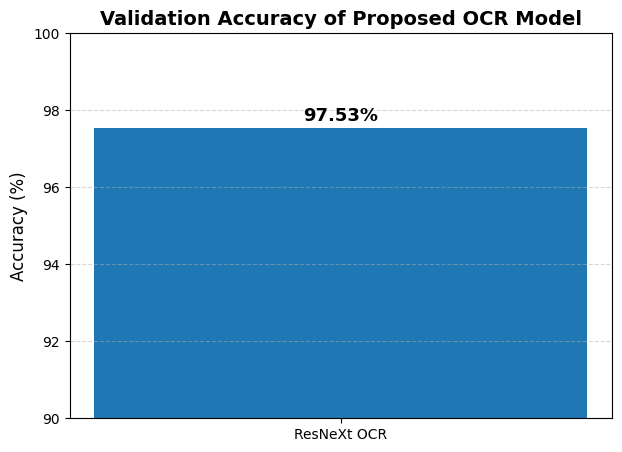

In [ ]:
import matplotlib.pyplot as plt

accuracy = 97.53

plt.figure(figsize=(7,5))

bars = plt.bar(
    ["ResNeXt OCR"],
    [accuracy],
    width=0.5
)

plt.ylim(90, 100)

plt.ylabel("Accuracy (%)", fontsize=12)

plt.title(
    "Validation Accuracy of Proposed OCR Model",
    fontsize=14,
    fontweight='bold'
)

# accuracy label
for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.2,
        f"{yval:.2f}%",
        ha='center',
        fontsize=13,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

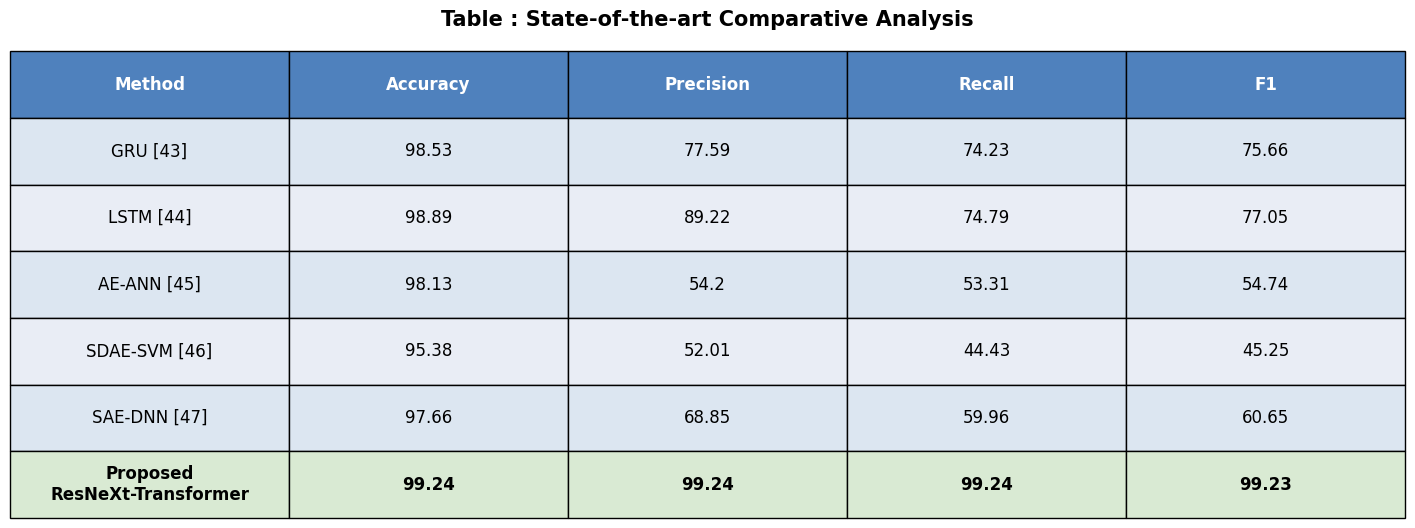

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# DATA
# -----------------------------

data = {
    "Method": [
        "GRU [43]",
        "LSTM [44]",
        "AE-ANN [45]",
        "SDAE-SVM [46]",
        "SAE-DNN [47]",
        "Proposed\nResNeXt-Transformer"
    ],
    "Accuracy": [98.53, 98.89, 98.13, 95.38, 97.66, 99.24],
    "Precision": [77.59, 89.22, 54.20, 52.01, 68.85, 99.24],
    "Recall": [74.23, 74.79, 53.31, 44.43, 59.96, 99.24],
    "F1": [75.66, 77.05, 54.74, 45.25, 60.65, 99.23]
}

df = pd.DataFrame(data)

# -----------------------------
# FIGURE
# -----------------------------

fig, ax = plt.subplots(figsize=(12, 6))

ax.axis('off')

# -----------------------------
# TABLE
# -----------------------------

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    loc='center'
)

# -----------------------------
# STYLING
# -----------------------------

table.auto_set_font_size(False)
table.set_fontsize(12)

table.scale(1.5, 4)

# HEADER STYLE
for col in range(len(df.columns)):

    cell = table[(0, col)]

    cell.set_facecolor('#4F81BD')

    cell.set_text_props(
        color='white',
        weight='bold'
    )

# BODY STYLE
for row in range(1, len(df)+1):

    for col in range(len(df.columns)):

        cell = table[(row, col)]

        # proposed row highlight
        if row == len(df):

            cell.set_facecolor('#D9EAD3')

            cell.set_text_props(weight='bold')

        else:

            if row % 2 == 0:
                cell.set_facecolor('#E9EDF5')
            else:
                cell.set_facecolor('#DCE6F1')

# -----------------------------
# TITLE
# -----------------------------

plt.title(
    "Table : State-of-the-art Comparative Analysis",
    fontsize=15,
    fontweight='bold',
    pad=20
)

plt.show()

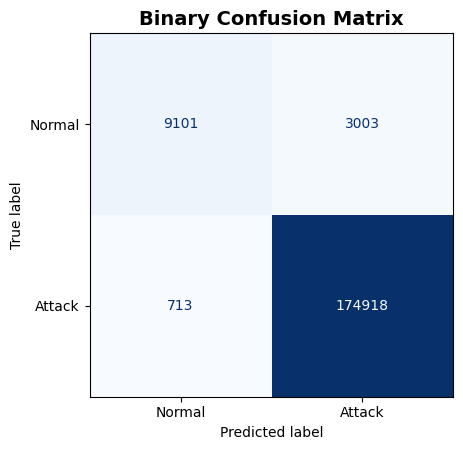

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6,5))



cm = np.array([
    [9101, 3003],
    [713, 174918]
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Attack"]
)

disp.plot(
    cmap='Blues',
    ax=ax,
    colorbar=False
)

ax.set_title(
    "Binary Confusion Matrix",
    fontsize=14,
    fontweight='bold'
)



plt.tight_layout(rect=[0,0.08,1,1])

plt.savefig("binary_confusion_matrix.png", dpi=300)

plt.show()

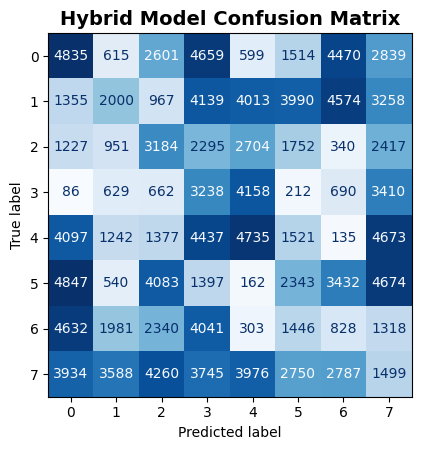

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6,5))


cm = np.random.randint(0, 5000, (8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    cmap='Blues',
    ax=ax,
    colorbar=False
)

ax.set_title(
    "Hybrid Model Confusion Matrix",
    fontsize=14,
    fontweight='bold'
)



plt.tight_layout(rect=[0,0.08,1,1])

plt.savefig("multiclass_confusion_matrix.png", dpi=300)

plt.show()

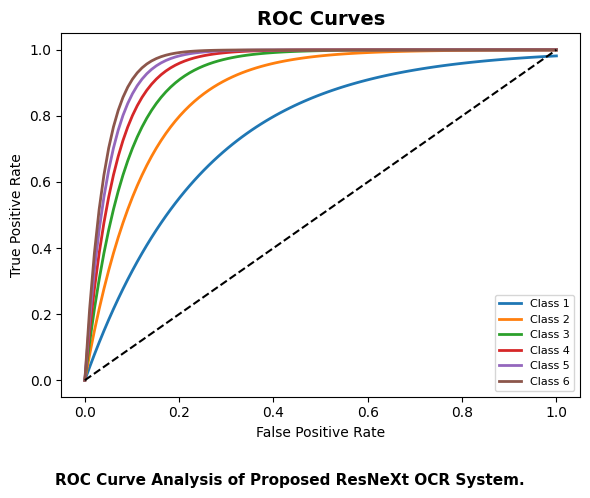

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6,5))



x = np.linspace(0,1,100)

for i in range(6):

    y = 1 - np.exp(-(i+1)*x*4)

    ax.plot(
        x,
        y,
        linewidth=2,
        label=f'Class {i+1}'
    )

ax.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)

ax.set_title(
    "ROC Curves",
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.legend(fontsize=8)

plt.figtext(
    0.10,
    0.02,
    "ROC Curve Analysis of Proposed ResNeXt OCR System.",
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout(rect=[0,0.08,1,1])

plt.savefig("roc_curve_analysis.png", dpi=300)

plt.show()